In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv('wine.csv')

In [47]:
df.shape

(178, 14)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [49]:
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [50]:
df.iloc[:, :3].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Wine        178 non-null    int64  
 1   Alcohol     178 non-null    float64
 2   Malic.acid  178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [51]:
df = df.iloc[0:, :3]

In [61]:
df.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

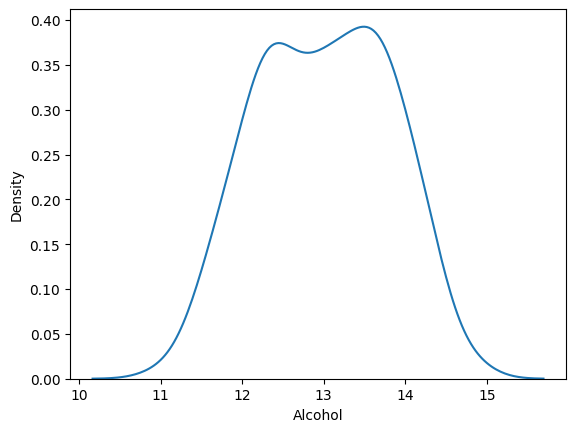

In [53]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic.acid', ylabel='Density'>

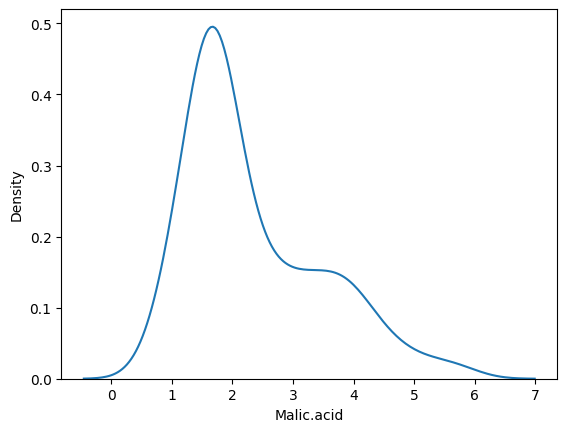

In [54]:
sns.kdeplot(df['Malic.acid'])

<Axes: xlabel='Alcohol', ylabel='Malic.acid'>

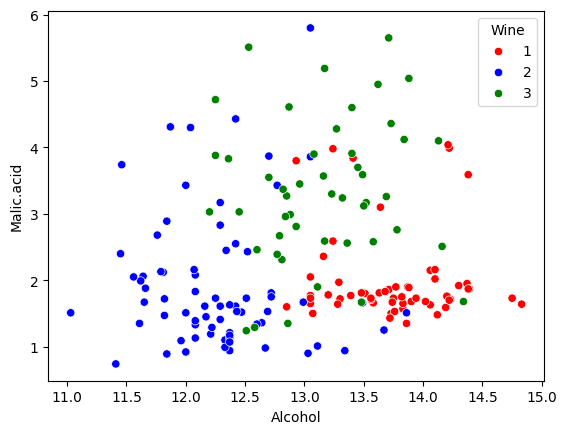

In [55]:
color_dict = {1: 'red', 3: 'green', 2: 'blue'}
sns.scatterplot(x = df['Alcohol'], y = df['Malic.acid'], hue=df['Wine'], palette=color_dict)

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Wine', axis=1), df['Wine'], test_size=0.2, random_state=0)

In [57]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [58]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [64]:
x_train_scaled

,Alcohol,Malic.acid
0,0.715054,0.513238
1,0.446237,0.160896
2,0.158602,0.254582
3,0.637097,0.645621
4,0.663978,0.217923
...,...,...
137,0.212366,0.199593
138,0.360215,0.087576
139,0.373656,0.177189
140,0.771505,0.191446


In [67]:
np.round(x_train.describe(), 1)

,Alcohol,Malic.acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [68]:
np.round(x_train_scaled.describe(), 1)

,Alcohol,Malic.acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

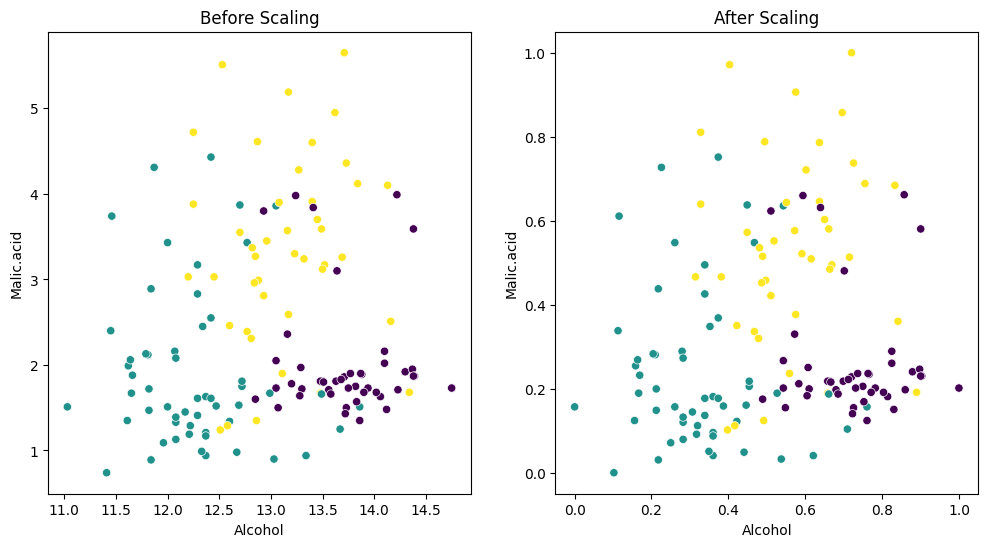

In [71]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

#befor scaling
sns.scatterplot(x = x_train['Alcohol'],y = x_train['Malic.acid'], c = y_train, ax=ax1)
ax1.set_title('Before Scaling')

#after scaling 
sns.scatterplot(x = x_train_scaled['Alcohol'],y = x_train_scaled['Malic.acid'], c = y_train, ax=ax2)
ax2.set_title('After Scaling')

Text(0.5, 1.0, 'After Scaling')

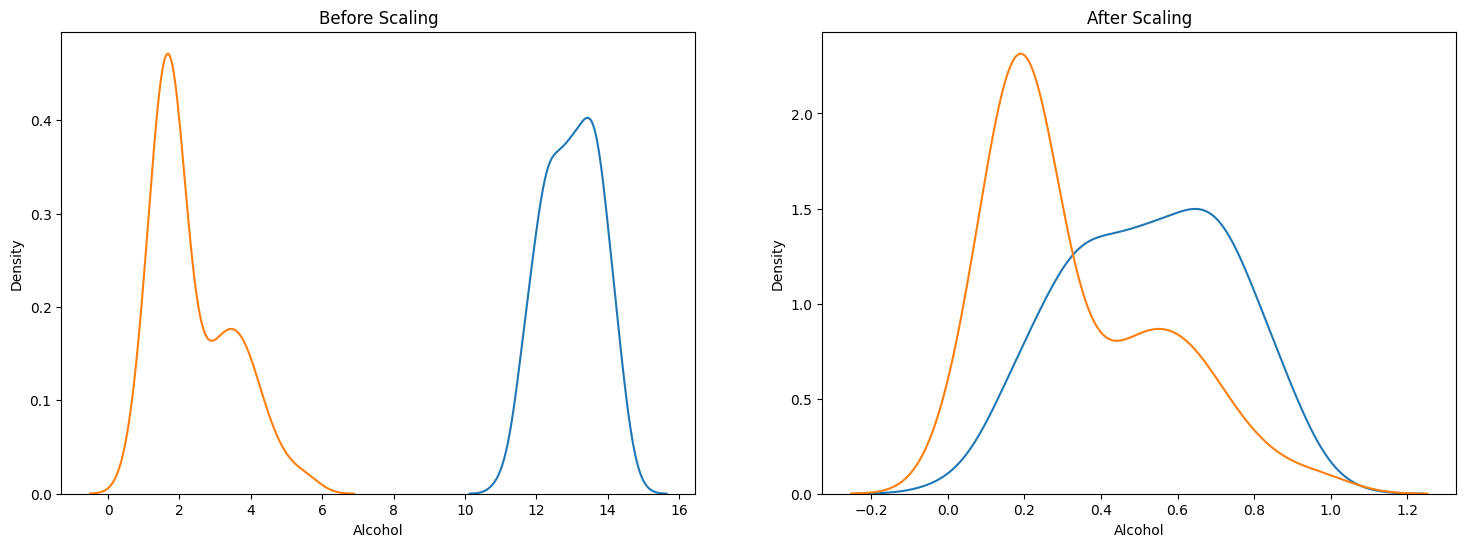

In [76]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(18,6))

#befor scaling
sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic.acid'], ax=ax1)
ax1.set_title('Before Scaling') 

#after scaling
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic.acid'], ax=ax2)
ax2.set_title('After Scaling')
